# Análisis Exploratorio de Datos (EDA)
## Dataset: Messy Clinic Appointments

**Asignatura:** SCY1101 - Programación para la Ciencia de Datos  
**Pregunta guía:** ¿Qué variables nos permiten predecir si un paciente necesita seguimiento (`follow_up_required`)?

El EDA sigue una línea lógica de 6 fases donde cada fase alimenta a la siguiente:

| Fase | Pregunta |
|---|---|
| 0 — Setup y Auditoría | ¿Puedo confiar en este archivo? |
| 1 — Vista General | ¿Qué tengo? |
| 2 — Diagnóstico de Calidad | ¿Qué está roto y por qué? |
| 3 — Preparación y Feature Engineering | ¿Cómo lo convierto en algo analizable? |
| 4 — Análisis del Target | ¿Qué estamos prediciendo? |
| 5 — Análisis de Predictores | ¿Qué variables discriminan el target? |
| 6 — Síntesis y Conclusiones | ¿Qué entra al modelo y qué no? |

---

### Diccionario de Variables

| Columna | Tipo | Descripción |
|---|---|---|
| `patient_id` | int | Identificador del paciente (no único por fila) |
| `patient_name` | str | Nombre del paciente |
| `age` | int | Edad del paciente |
| `gender` | str | Género (con múltiples representaciones) |
| `appointment_date` | str | Fecha de la cita (múltiples formatos) |
| `booking_date` | str | Fecha en que se agendó la cita |
| `doctor` | str | Nombre del médico |
| `department` | str | Departamento clínico |
| `billing_amount` | str | Monto cobrado (con símbolos de moneda) |
| `follow_up_required` | str | **Variable objetivo** (múltiples representaciones de Sí/No) |


---
## FASE 0 — Setup y Auditoría de Integridad

> *¿Puedo confiar en este archivo?*

Antes de explorar cualquier dato verificamos que el archivo no fue modificado desde que lo recibimos.  
Si el hash SHA-256 cambia → el CSV fue alterado o está corrupto → todo análisis posterior sería inválido.


### 0.1 Configuración del entorno

In [2]:
import sys
import os
sys.path.append('..')  # Para importar desde src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Rutas
from src.config import RAW_CSV, OUTPUTS_DIR
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f"Entorno configurado correctamente.")
print(f"   Dataset: {RAW_CSV}")
print(f"   Outputs: {OUTPUTS_DIR}")


Entorno configurado correctamente.
   Dataset: c:\GitHub\EDA-Messy-Clinic-Appointments\notebooks\..\data\raw\messy_clinic_appointments.csv
   Outputs: c:\GitHub\EDA-Messy-Clinic-Appointments\notebooks\..\outputs


### 0.2 Verificación de integridad (SHA-256)

Antes de explorar cualquier dato, verificamos que el archivo no fue modificado
desde que lo recibimos. Usamos el hash SHA-256 almacenado en `metadata.json`.

Si el hash cambia → alguien modificó el CSV sin autorización o se corrompió.


In [3]:
from src.audit import create_metadata_file, verify_data_integrity
from src.config import METADATA_JSON

# Creamos el metadata.json si no existe (solo se ejecuta una vez)
if not os.path.exists(METADATA_JSON):
    print("Primera ejecución: generando metadata.json...")
    create_metadata_file(str(RAW_CSV), str(METADATA_JSON))

# Verificamos integridad
integrity_ok = verify_data_integrity(str(RAW_CSV), str(METADATA_JSON))
if not integrity_ok:
    print("ALERTA: La integridad del dataset está comprometida. Revisa el archivo antes de continuar.")
else:
    print("Integridad verificada: OK")


INFO: Verificando integridad de: messy_clinic_appointments.csv
CRITICAL: ALERTA: Discrepancia detectada en el dataset.
CRITICAL:   Hash esperado: d2b86beb66a83546c3e202b958b76c0a0115ed46d73d1173d1e71f0595b8effc
CRITICAL:   Hash actual:   b6dada1cc070f279e05a59ba9f184d72af42eb1698cafd98144a702438687526


INFO: Verificando integridad de: messy_clinic_appointments.csv
CRITICAL: ALERTA: Discrepancia detectada en el dataset.
CRITICAL:   Hash esperado: d2b86beb66a83546c3e202b958b76c0a0115ed46d73d1173d1e71f0595b8effc
CRITICAL:   Hash actual:   b6dada1cc070f279e05a59ba9f184d72af42eb1698cafd98144a702438687526


ALERTA: La integridad del dataset está comprometida. Revisa el archivo antes de continuar.


---
## FASE 1 — Vista General del Dataset

> *¿Qué tengo?*

Cargamos el CSV y obtenemos el mapa del territorio: dimensiones, tipos de datos y estadísticas descriptivas.  
Aquí solo describimos, no juzgamos todavía.


In [4]:
df = pd.read_csv(RAW_CSV)

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(8)


Dimensiones: 1000 filas × 10 columnas


,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
0,1080,Tammy Williams,76,female,2026/02/26,2024/12/03,Christopher Graham,Cardiology,£425.8,1
1,1074,Megan Strickland,69,F,05/23/2025,12-Jun-2024,Brandon Lewis,Orthopedics,€344.26,Y
2,1067,Amanda Schroeder,79,M,30-Nov-2025,"August 05, 24",Deanna Edwards,Neurology,€203.34,Y
3,1072,Anthony Mcpherson,47,F,"May 18, 25",09/09/2024,Karen Parsons,General,Rs85.76,No
4,1092,Benjamin Brown,45,NaN,2026/03/07,08/17/2024,Andrea Hernandez,General,$84.44,1
5,1057,Joe Sharp,78,1,"September 26, 25",08/31/2025,Kimberly Fields,General,NaN,Yes
6,1018,Alexander Harris,22,Female,30-Oct-2025,12/29/2024,Jim Jones,Cardiology,€99.0,No
7,1074,Raymond Williams,57,M,2025/04/23,28-Mar-2025,James Brooks,Neurology,Rs374.63,No


In [89]:
# Resumen de tipos de datos y valores no nulos
print("=== Información general ===")
df.info()


=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   patient_id          1000 non-null   int64
 1   patient_name        1000 non-null   str  
 2   age                 1000 non-null   int64
 3   gender              950 non-null    str  
 4   appointment_date    1000 non-null   str  
 5   booking_date        1000 non-null   str  
 6   doctor              1000 non-null   str  
 7   department          1000 non-null   str  
 8   billing_amount      950 non-null    str  
 9   follow_up_required  1000 non-null   str  
dtypes: int64(2), str(8)
memory usage: 78.3 KB


---
## FASE 2 — Diagnóstico de Calidad de Datos

> *¿Qué está roto y por qué?*

Inspeccionamos cada columna en busca de problemas: nulos, encodings inconsistentes, tipos erróneos y formatos mezclados.  
Esta fase termina con la **tabla de decisiones de transformación**, que es el output concreto del diagnóstico.


### 2.1 Nulos reales

El dataset usa `NaN` real en algunas columnas, pero también representa datos faltantes con otros encodings (ver secciones siguientes). Aquí vemos solo los nulos reales.


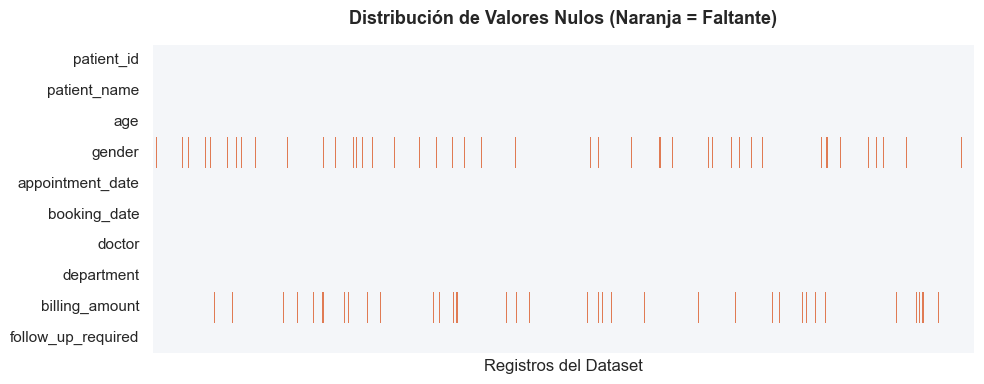

In [91]:
# ── VERSIÓN 1: Heatmap Minimalista ──
fig, ax = plt.subplots(figsize=(10, 4))

# Colores personalizados: Gris claro (Dato válido) y Rojo/Naranja (Nulo)
cmap_nulos = sns.color_palette(["#f4f6f9", "#E07B54"])

sns.heatmap(
    df.isnull().T,
    cmap=cmap_nulos,
    cbar=False,
    xticklabels=False, # Ocultamos el ruido del índice
    ax=ax
)
ax.set_title('Distribución de Valores Nulos (Naranja = Faltante)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Registros del Dataset')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'nulos_heatmap_minimalista.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Variable objetivo: `follow_up_required`

**Problema detectado:** La variable objetivo tiene **6 representaciones distintas** para solo 2 significados:
- Positivo (necesita seguimiento): `Yes`, `Y`, `1`
- Negativo (no necesita): `No`, `N`, `0`

Esto es típico de datos reales donde distintos operadores ingresaron la información de formas diferentes. **Debe normalizarse antes de cualquier análisis.**


In [92]:
# Ver todas las variantes tal como están en el CSV
print("Variantes encontradas en follow_up_required:")
print(df['follow_up_required'].value_counts(dropna=False))


Variantes encontradas en follow_up_required:
follow_up_required
0      185
Y      182
Yes    181
N      154
1      151
No     147
Name: count, dtype: int64


### 2.3 Columna `gender`

**Problema detectado:** La columna tiene **8 representaciones distintas** más valores nulos.


In [93]:
print("Variantes en gender:")
print(df['gender'].value_counts(dropna=False))


Variantes en gender:
gender
0         129
1         128
Male      123
Female    120
F         116
female    112
male      112
M         110
NaN        50
Name: count, dtype: int64


### 2.4 Columna `billing_amount`

**Problema detectado:** La columna es de tipo texto (`object`) y contiene **4 símbolos de moneda distintos** mezclados: `£`, `€`, `$`, `Rs`. Además tiene 50 valores nulos.


In [94]:
print("Muestra de valores en billing_amount:")
print(df['billing_amount'].dropna().head(12).tolist())
print(f"\nNulos: {df['billing_amount'].isna().sum()}")

# Contar símbolos presentes
import re
simbolos = df['billing_amount'].dropna().str.extract(r'([^\d.,]+)')[0].value_counts()
print("\nSímbolos encontrados:")
print(simbolos)


Muestra de valores en billing_amount:
['£425.8', '€344.26', '€203.34', 'Rs85.76', '$84.44', '€99.0', 'Rs374.63', '$452.37', '€494.97', '£91.91', '$82.88', 'Rs277.14']

Nulos: 50

Símbolos encontrados:
0
Rs    252
$     241
€     237
£     220
Name: count, dtype: int64


### 2.5 Columnas de fecha: `appointment_date` y `booking_date`

**Problema detectado:** Ambas columnas de fecha usan **4 formatos distintos** en el mismo campo:
`2026/02/26`, `05/23/2025`, `30-Nov-2025`, `May 18, 25`


### 2.6 Resumen: Decisiones de Transformación

Esta tabla es el output concreto de la fase de diagnóstico. Resume todos los problemas encontrados y las decisiones que tomamos, las cuales se implementan en `src/transformers.py` y `src/pipeline.py`.

| Columna | Problema detectado | Decisión de transformación |
|---|---|---|
| `patient_name` | Sin valor predictivo (identidad) | Eliminar (`DropColumnsTransformer`) |
| `patient_id` | 899 duplicados — legítimos (un paciente, varias citas) | Mantener sin cambios |
| `gender` | 8 variantes + 50 nulos | `GenderNormalizerTransformer` → imputar moda |
| `age` | Limpio, rango 18-90 | `OutlierCapper` + `StandardScaler` |
| `appointment_date` | 4 formatos de texto distintos | `DateFeatureTransformer` → `waiting_days`, `appointment_dow` |
| `booking_date` | 4 formatos de texto distintos | Usada para calcular `waiting_days`, luego eliminar |
| `doctor` | 990 valores únicos (alta cardinalidad) | Eliminar (`DropColumnsTransformer`) |
| `department` | 4 valores, limpio | `OneHotEncoder` |
| `billing_amount` | Texto con símbolo de moneda + 50 nulos | `BillingCleanerTransformer` → imputar mediana |
| `follow_up_required` | 6 variantes → binario | Normalizar a `1/0` antes del pipeline |

Con el diagnóstico completo, la siguiente fase aplica estas decisiones para poder analizar los datos correctamente.


---
## FASE 3 — Preparación y Feature Engineering

> *¿Cómo convierto lo roto en algo analizable?*

Aplicamos las decisiones de la Fase 2 para transformar las columnas problemáticas.  
Sin este paso, los gráficos de las fases siguientes serían sobre datos sucios y sus conclusiones serían inválidas.


### 3.1 Normalizar `follow_up_required` → `follow_up_bin`

In [11]:
# Función de normalización
def normalize_follow_up(x):
    """Convierte las 6 variantes de follow_up_required a binario 1/0."""
    x = str(x).strip().lower()
    if x in ['yes', 'y', '1']:
        return 1
    elif x in ['no', 'n', '0']:
        return 0
    return np.nan  # Si hubiera un valor inesperado

df['follow_up_bin'] = df['follow_up_required'].apply(normalize_follow_up)

print("Después de normalizar:")
print(df['follow_up_bin'].value_counts(dropna=False))
print(f"\nNulos generados por normalización: {df['follow_up_bin'].isna().sum()}")


Después de normalizar:
follow_up_bin
1    514
0    486
Name: count, dtype: int64

Nulos generados por normalización: 0


=== Estadísticas Descriptivas ===

ANTES Y DESPUÉS: Normalización de follow_up_required



=== Estadísticas Descriptivas ===

ANTES Y DESPUÉS: Normalización de follow_up_required



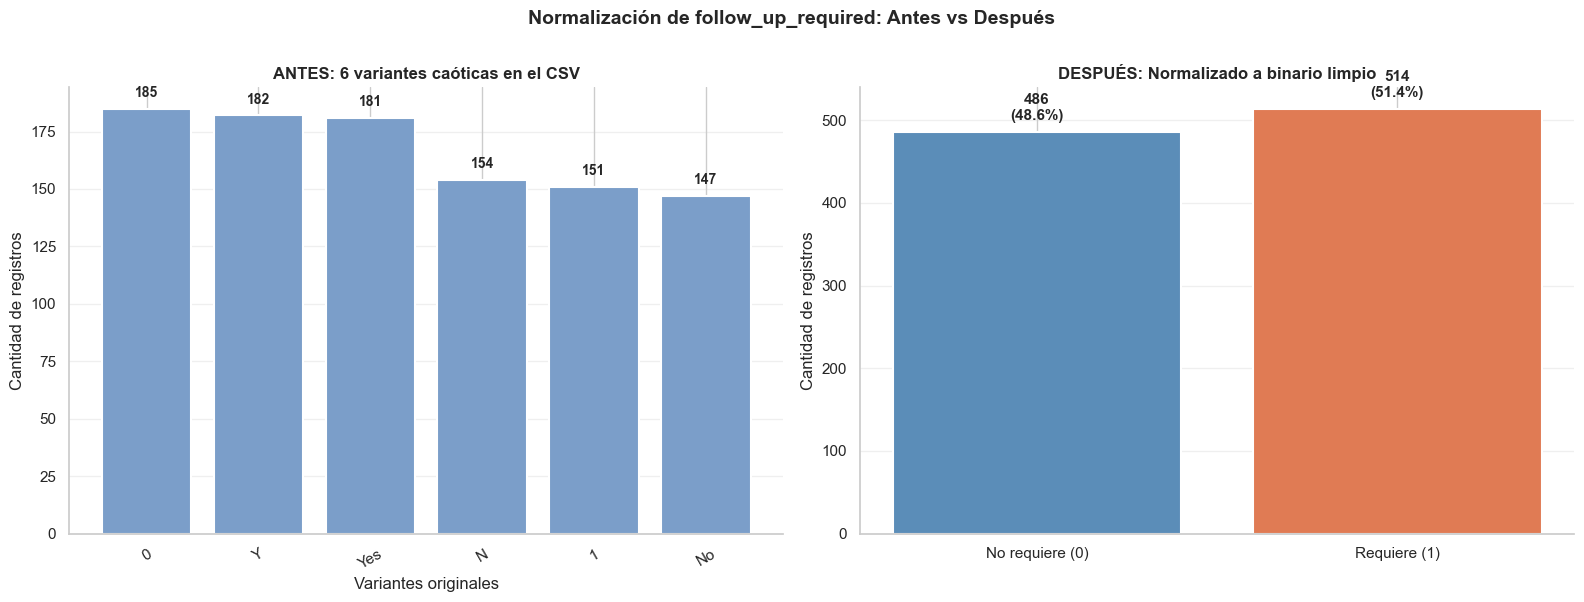

Normalización completada:
   • 0 (No requiere) → 486 registros (48.6%)
   • 1 (Requiere)    → 514 registros (51.4%)

→ Variable balanceada: lista para análisis


In [12]:
# Estadísticas descriptivas de columnas numéricas
print("=== Estadísticas Descriptivas ===")
df.describe().round(2)

# ===== GRÁFICO ANTES Y DESPUÉS: follow_up_required =====
print("\n" + "="*80)
print("ANTES Y DESPUÉS: Normalización de follow_up_required")
print("="*80 + "\n")

# ANTES: Variantes originales
antes = df['follow_up_required'].value_counts(dropna=False)
labels_antes = [str(v) if str(v) != 'nan' else 'NaN' for v in antes.index]

# DESPUÉS: Normalizar y contar
def normalize_follow_up(x):
    """Convierte las 6 variantes de follow_up_required a binario 1/0."""
    x = str(x).strip().lower()
    if x in ['yes', 'y', '1']:
        return 1
    elif x in ['no', 'n', '0']:
        return 0
    return np.nan

df['follow_up_bin'] = df['follow_up_required'].apply(normalize_follow_up)
despues = df['follow_up_bin'].value_counts(dropna=False).sort_index()
labels_despues = ['No requiere (0)', 'Requiere (1)']

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANTES
axes[0].bar(labels_antes, antes.values, color='#7B9EC9', edgecolor='white', linewidth=1.5)
axes[0].set_title('ANTES: 6 variantes caóticas en el CSV', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Variantes originales')
axes[0].set_ylabel('Cantidad de registros')
axes[0].tick_params(axis='x', rotation=30)
for i, val in enumerate(antes.values):
    axes[0].text(i, val + max(antes.values) * 0.02, str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# DESPUÉS
colors_despues = ['#5B8DB8', '#E07B54']
bars = axes[1].bar(labels_despues, despues.values, color=colors_despues, edgecolor='white', linewidth=1.5)
axes[1].set_title('DESPUÉS: Normalizado a binario limpio', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cantidad de registros')
axes[1].grid(axis='y', alpha=0.3)

# Porcentajes en el gráfico DESPUÉS
total = despues.sum()
for bar, val in zip(bars, despues.values):
    pct = 100 * val / total
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Normalización de follow_up_required: Antes vs Después', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'follow_up_before_after_simple.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Normalización completada:")
print(f"   • 0 (No requiere) → {despues[0]} registros ({100*despues[0]/total:.1f}%)")
print(f"   • 1 (Requiere)    → {despues[1]} registros ({100*despues[1]/total:.1f}%)")
print(f"\n→ Variable balanceada: lista para análisis")


### 3.2 Normalizar `gender` → `gender_norm`

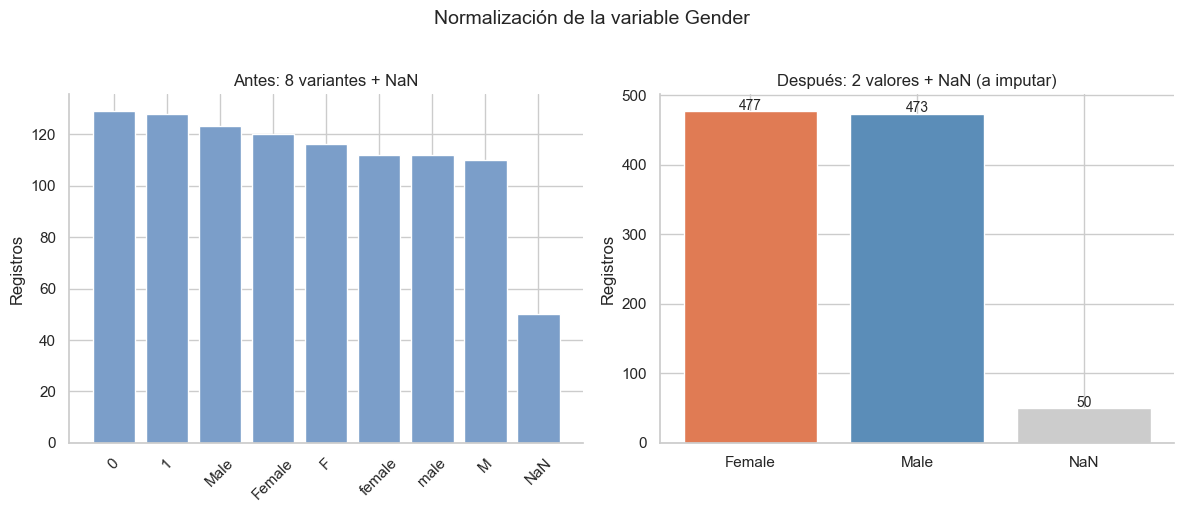


Nulos después de normalizar: 50 (serán imputados con moda)


In [96]:
# Normalizar para visualización
GENDER_MAP = {
    'male': 'Male', 'm': 'Male', '1': 'Male',
    'female': 'Female', 'f': 'Female', '0': 'Female'
}
df['gender_norm'] = df['gender'].str.strip().str.lower().map(GENDER_MAP)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes
variantes = df['gender'].value_counts(dropna=False)
labels_antes = [str(v) if str(v) != 'nan' else 'NaN' for v in variantes.index]
axes[0].bar(labels_antes, variantes.values, color='#7B9EC9', edgecolor='white')
axes[0].set_title('Antes: 8 variantes + NaN', fontsize=12)
axes[0].set_ylabel('Registros')
axes[0].tick_params(axis='x', rotation=45)

# Después
norm_counts = df['gender_norm'].value_counts(dropna=False)
labels_despues = [str(v) if str(v) != 'nan' else 'NaN' for v in norm_counts.index]
colors_d = ['#E07B54' if l == 'Female' else '#5B8DB8' if l == 'Male' else '#CCCCCC' for l in labels_despues]
axes[1].bar(labels_despues, norm_counts.values, color=colors_d, edgecolor='white')
axes[1].set_title('Después: 2 valores + NaN (a imputar)', fontsize=12)
axes[1].set_ylabel('Registros')
for i, (label, val) in enumerate(zip(labels_despues, norm_counts.values)):
    axes[1].text(i, val + 2, str(val), ha='center', fontsize=10)

plt.suptitle('Normalización de la variable Gender', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'gender_normalization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nNulos después de normalizar: {df['gender_norm'].isna().sum()} (serán imputados con moda)")


### 3.3 Limpiar `billing_amount` → `billing_clean`

Estadísticas de la variable puramente numérica (Después):
count    950.00
mean     276.12
std      130.12
min       51.38
25%      162.95
50%      269.84
75%      389.23
max      499.75
Name: billing_clean, dtype: float64


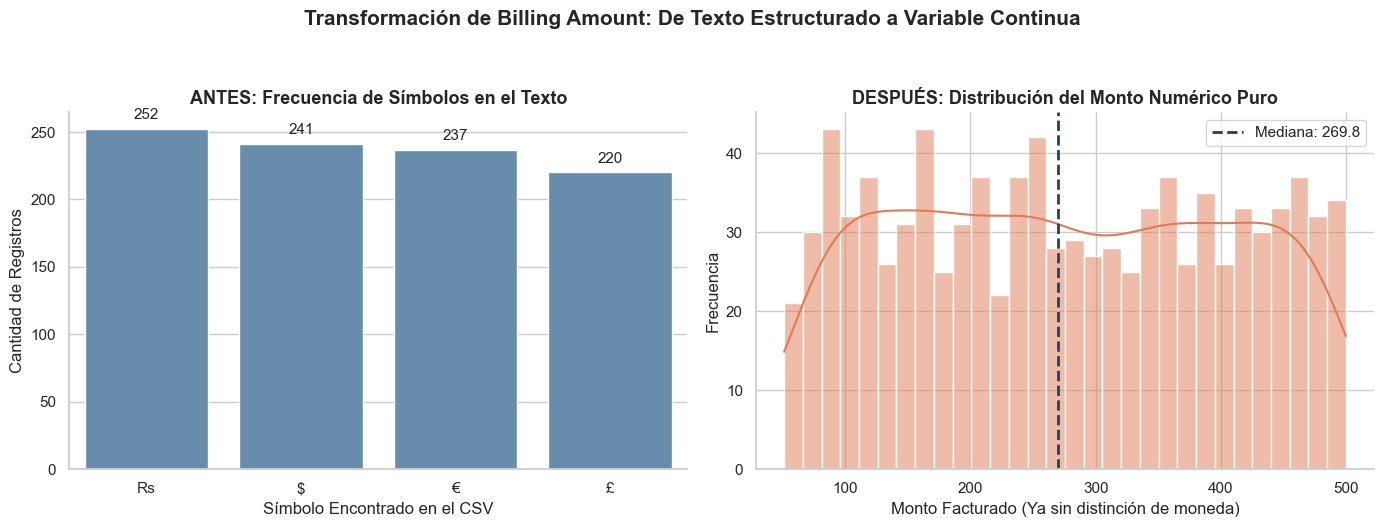

In [16]:
# 1. Extraer los símbolos para mostrar el problema original (ANTES)
df['simbolo_original'] = df['billing_amount'].dropna().astype(str).str.extract(r'([^\d.,]+)')[0].fillna('Sin Símbolo')

# 2. Tu código de limpieza (RegEx) para obtener el número puro (DESPUÉS)
df['billing_clean'] = (
    df['billing_amount']
    .astype(str)
    .str.strip()
    .replace(r'^\.+$', np.nan, regex=True)
    .str.replace(r'[^\d.,]+', '', regex=True)
    .str.replace(',', '.', regex=False)
)
df['billing_clean'] = pd.to_numeric(df['billing_clean'], errors='coerce')

print("Estadísticas de la variable puramente numérica (Después):")
print(df['billing_clean'].describe().round(2))

# --- VISUALIZACIÓN: EL VERDADERO ANTES Y DESPUÉS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRÁFICO 1: ANTES (El conteo de los símbolos de texto)
sns.countplot(
    data=df, 
    x='simbolo_original', 
    order=df['simbolo_original'].value_counts().index, 
    color='#5B8DB8', 
    ax=axes[0]
)
axes[0].set_title('ANTES: Frecuencia de Símbolos en el Texto', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Símbolo Encontrado en el CSV')
axes[0].set_ylabel('Cantidad de Registros')

# Añadir las cantidades exactas arriba de cada barra para máximo detalle
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

# GRÁFICO 2: DESPUÉS (El monto como un valor puramente numérico)
sns.histplot(
    df['billing_clean'].dropna(), 
    bins=30, 
    kde=True, 
    color='#E07B54', 
    edgecolor='white',
    linewidth=1,
    ax=axes[1]
)
axes[1].set_title('DESPUÉS: Distribución del Monto Numérico Puro', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monto Facturado (Ya sin distinción de moneda)')
axes[1].set_ylabel('Frecuencia')

# Añadir línea de la mediana
mediana = df['billing_clean'].median()
axes[1].axvline(mediana, color='#2C3E50', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.1f}')
axes[1].legend()

plt.suptitle('Transformación de Billing Amount: De Texto Estructurado a Variable Continua', fontsize=15, y=1.05, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'billing_antes_despues_real.png', dpi=150, bbox_inches='tight')
plt.show()

# Limpiamos la columna temporal de símbolos que ya no usaremos
df.drop(columns=['simbolo_original'], inplace=True, errors='ignore')

### 3.4 Parsear fechas y extraer features temporales

En lugar de usar las fechas como texto (inutilizables para un modelo), extraemos información útil:
- `waiting_days`: días entre la reserva y la cita
- `appointment_dow`: día de la semana de la cita (0=Lunes, 6=Domingo)


In [17]:
# Parsear con format='mixed' (pandas 2.x)
appt_dates    = pd.to_datetime(df['appointment_date'], format='mixed', errors='coerce')
booking_dates = pd.to_datetime(df['booking_date'],     format='mixed', errors='coerce')

df['waiting_days']    = (appt_dates - booking_dates).dt.days
df['appointment_dow'] = appt_dates.dt.dayofweek

print("Estadísticas de waiting_days:")
print(df['waiting_days'].describe().round(1))
print(f"\nValores negativos: {(df['waiting_days'] < 0).sum()} (citas antes de la reserva - error)")
print(f"Nulos en waiting_days: {df['waiting_days'].isna().sum()}")
print(f"\nDistribución día de la semana:")
dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
dow_counts = df['appointment_dow'].value_counts().sort_index()
for i, c in enumerate(dow_counts):
    print(f"  {dias[i]}: {c}")


Estadísticas de waiting_days:
count    1000.0
mean      274.6
std       170.5
min         2.0
25%       130.8
50%       258.5
75%       395.2
max       728.0
Name: waiting_days, dtype: float64

Valores negativos: 0 (citas antes de la reserva - error)
Nulos en waiting_days: 0

Distribución día de la semana:
  Lunes: 138
  Martes: 140
  Miércoles: 154
  Jueves: 146
  Viernes: 141
  Sábado: 126
  Domingo: 155


Estadísticas de waiting_days:
count    1000.0
mean      274.6
std       170.5
min         2.0
25%       130.8
50%       258.5
75%       395.2
max       728.0
Name: waiting_days, dtype: float64

Valores negativos: 0 (citas antes de la reserva - error)
Nulos en waiting_days: 0


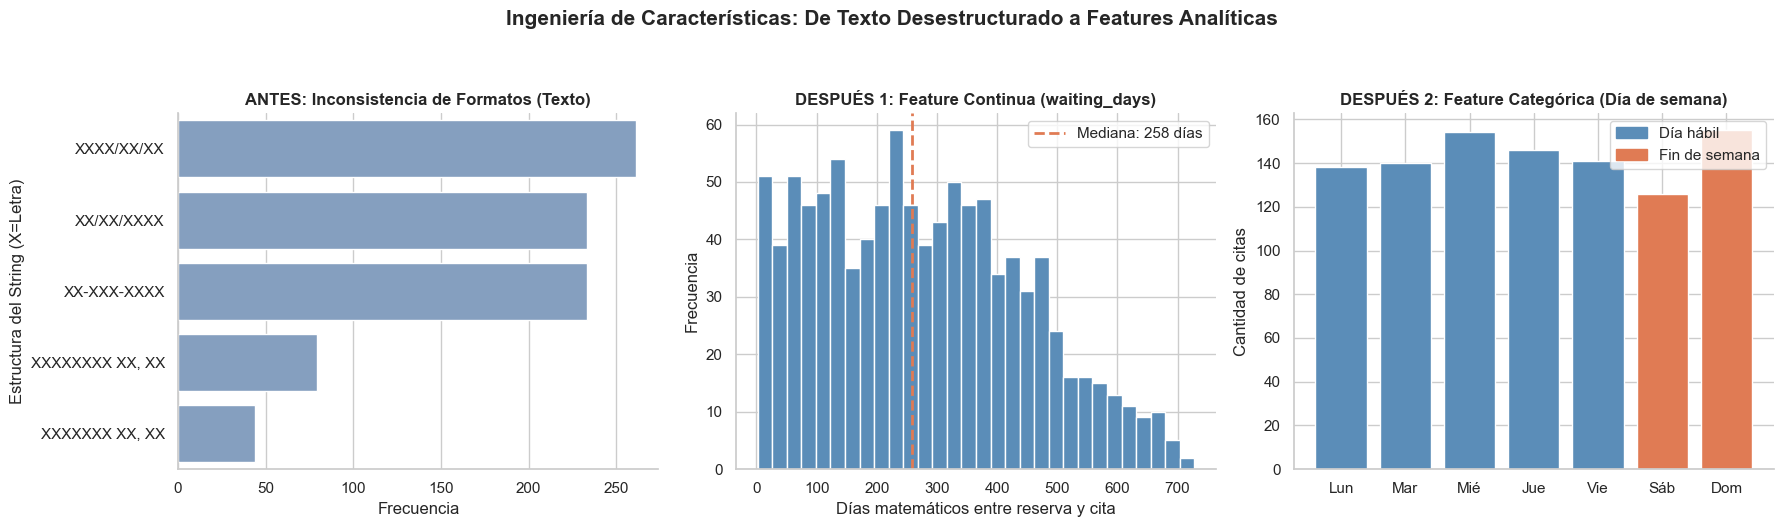

In [21]:
import matplotlib.patches as mpatches
import numpy as np

# --- 1. EL ANTES: Diagnóstico del formato crudo ---
# Reemplazamos los números por 'X' y letras por 'L' para visualizar las estructuras (ej. 'XXXX-XX-XX' vs 'XX/XX/XXXX')
df['formato_crudo'] = (
    df['appointment_date']
    .astype(str)
    .str.replace(r'\d', 'X', regex=True)
    .str.replace(r'[a-zA-Z]', 'X', regex=True)
)

# --- 2. LA TRANSFORMACIÓN: Tu código original ---
appt_dates    = pd.to_datetime(df['appointment_date'], format='mixed', errors='coerce')
booking_dates = pd.to_datetime(df['booking_date'],     format='mixed', errors='coerce')

df['waiting_days']    = (appt_dates - booking_dates).dt.days
df['appointment_dow'] = appt_dates.dt.dayofweek

print("Estadísticas de waiting_days:")
print(df['waiting_days'].describe().round(1))
print(f"\nValores negativos: {(df['waiting_days'] < 0).sum()} (citas antes de la reserva - error)")
print(f"Nulos en waiting_days: {df['waiting_days'].isna().sum()}")

# --- 3. VISUALIZACIÓN: ANTES Y DESPUÉS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PANEL 1 (EL ANTES): Caos de formatos estructurales
formatos_top = df['formato_crudo'].value_counts().head(5)
sns.barplot(x=formatos_top.values, y=formatos_top.index, color='#7B9EC9', ax=axes[0])
axes[0].set_title('ANTES: Inconsistencia de Formatos (Texto)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Estructura del String (X=Letra)')

# PANEL 2 (EL DESPUÉS 1): Variable Continua (Días de espera)
axes[1].hist(df['waiting_days'].dropna(), bins=30, color='#5B8DB8', edgecolor='white')
axes[1].axvline(df['waiting_days'].median(), color='#E07B54', linewidth=2,
                linestyle='--', label=f"Mediana: {df['waiting_days'].median():.0f} días")
axes[1].set_title('DESPUÉS 1: Feature Continua (waiting_days)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Días matemáticos entre reserva y cita')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# PANEL 3 (EL DESPUÉS 2): Variable Categórica Limpia (Día de semana)
dias_cortos = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
dow_vals = df['appointment_dow'].value_counts().sort_index()
colors_dow = ['#E07B54' if d >= 5 else '#5B8DB8' for d in range(7)]
axes[2].bar(dias_cortos, dow_vals.values, color=colors_dow, edgecolor='white')
axes[2].set_title('DESPUÉS 2: Feature Categórica (Día de semana)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Cantidad de citas')
weekend_patch = mpatches.Patch(color='#E07B54', label='Fin de semana')
week_patch    = mpatches.Patch(color='#5B8DB8', label='Día hábil')
axes[2].legend(handles=[week_patch, weekend_patch])

plt.suptitle('Ingeniería de Características: De Texto Desestructurado a Features Analíticas', fontsize=15, y=1.05, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'date_transformation_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

# Limpieza de la columna temporal
df.drop(columns=['formato_crudo'], inplace=True, errors='ignore')

---
## FASE 4 — Análisis de la Variable Objetivo

> *¿Qué estamos prediciendo?*

Con los datos ya limpios, analizamos `follow_up_bin` para entender la distribución del target.  
Esta es la pregunta más importante antes de analizar cualquier predictor: ¿el problema de clasificación está desbalanceado?


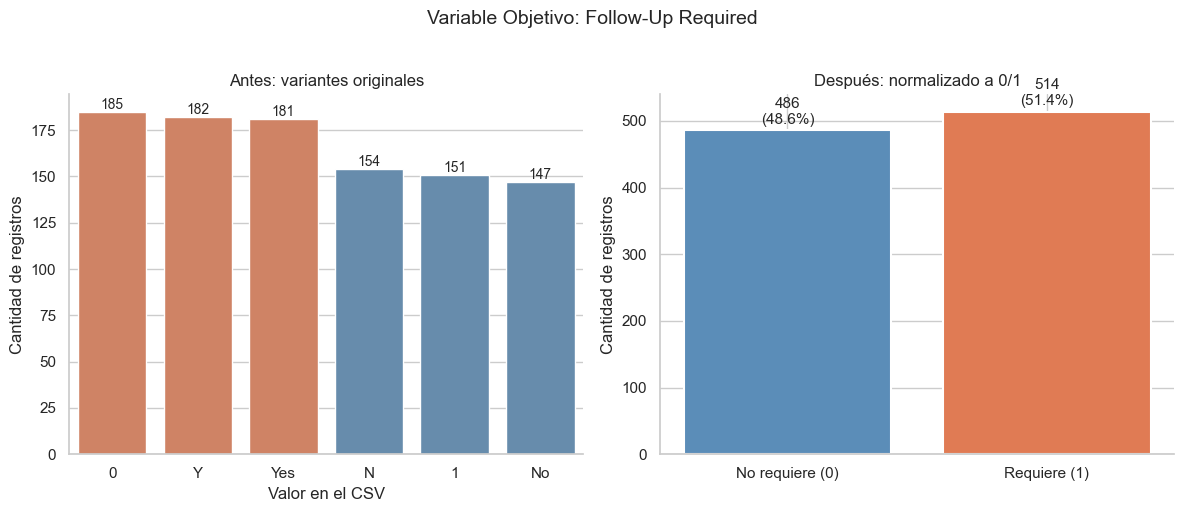

In [100]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico izquierdo: antes (con variantes)
orden_variantes = df['follow_up_required'].value_counts().index
colores_variantes = ['#E07B54', '#E07B54', '#E07B54', '#5B8DB8', '#5B8DB8', '#5B8DB8']
sns.countplot(
    data=df, x='follow_up_required',
    order=orden_variantes,
    palette=colores_variantes,
    ax=axes[0]
)
axes[0].set_title('Antes: variantes originales', fontsize=12)
axes[0].set_xlabel('Valor en el CSV')
axes[0].set_ylabel('Cantidad de registros')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Gráfico derecho: después (binario)
conteos = df['follow_up_bin'].value_counts().sort_index()
bars = axes[1].bar(
    ['No requiere (0)', 'Requiere (1)'],
    conteos.values,
    color=['#5B8DB8', '#E07B54'],
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Después: normalizado a 0/1', fontsize=12)
axes[1].set_ylabel('Cantidad de registros')
total = conteos.sum()
for bar, val in zip(bars, conteos.values):
    pct = 100 * val / total
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

plt.suptitle('Variable Objetivo: Follow-Up Required', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


**Hallazgo:** La variable objetivo está prácticamente **balanceada** (~51% necesita seguimiento
vs ~49% no). Esto es favorable para el modelado: no necesitaremos técnicas de balanceo
de clases como SMOTE o class_weight.


---
## FASE 5 — Análisis de Predictores en Relación al Target

> *¿Qué variables discriminan entre pacientes que necesitan seguimiento y los que no?*

Con el target entendido, analizamos cada variable **en función de su relación con `follow_up_bin`**.  
Buscamos patrones que sugieran poder predictivo.


### 5.1 Variables numéricas: distribuciones por clase

Comparamos la distribución de cada variable numérica entre pacientes que necesitan seguimiento (1) y los que no (0).  
Si las distribuciones se solapan completamente → la variable no discrimina. Si se separan → hay señal predictiva.


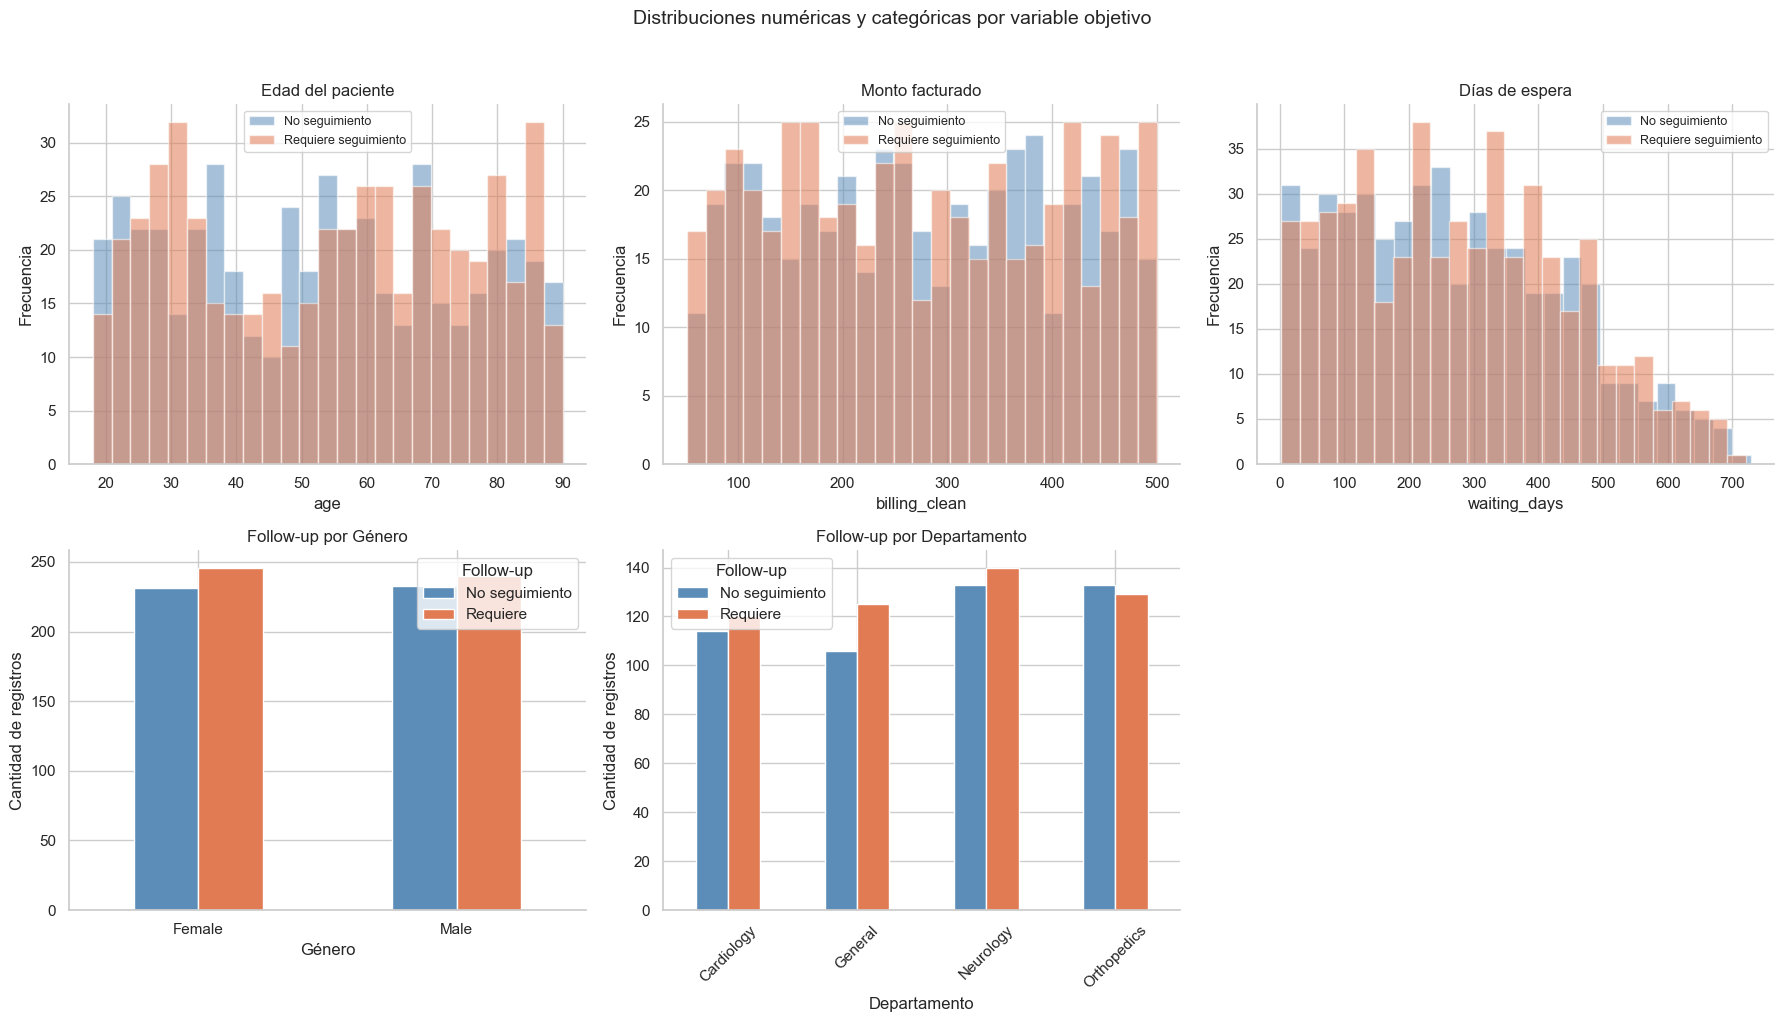

In [114]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

numeric_vars = [
    ('age', 'Edad del paciente'),
    ('billing_clean', 'Monto facturado'),
    ('waiting_days', 'Días de espera')
]

for ax, (col, label) in zip(axes[:3], numeric_vars):
    for val, color, nombre in [(0, '#5B8DB8', 'No seguimiento'), (1, '#E07B54', 'Requiere seguimiento')]:
        subset = df[df['follow_up_bin'] == val][col].dropna()
        ax.hist(subset, bins=25, alpha=0.55, color=color, label=nombre, edgecolor='white')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

# Follow-up por género
gender_counts = df.groupby(['gender_norm', 'follow_up_bin']).size().unstack(fill_value=0)
gender_counts.plot(kind='bar', ax=axes[3], color=['#5B8DB8', '#E07B54'], edgecolor='white')
axes[3].set_title('Follow-up por Género', fontsize=12)
axes[3].set_xlabel('Género')
axes[3].set_ylabel('Cantidad de registros')
axes[3].legend(['No seguimiento', 'Requiere'], title='Follow-up')
axes[3].tick_params(axis='x', rotation=0)

# Follow-up por departamento
dept_counts = df.groupby(['department', 'follow_up_bin']).size().unstack(fill_value=0)
dept_counts.plot(kind='bar', ax=axes[4], color=['#5B8DB8', '#E07B54'], edgecolor='white')
axes[4].set_title('Follow-up por Departamento', fontsize=12)
axes[4].set_xlabel('Departamento')
axes[4].set_ylabel('Cantidad de registros')
axes[4].legend(['No seguimiento', 'Requiere'], title='Follow-up')
axes[4].tick_params(axis='x', rotation=45)

axes[5].axis('off')

plt.suptitle('Distribuciones numéricas y categóricas por variable objetivo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'numeric_and_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Detección y tratamiento de outliers

Usamos el método IQR (Rango Intercuartílico):
- Límite inferior = Q1 − 1.5 × IQR
- Límite superior = Q3 + 1.5 × IQR

En lugar de eliminar la fila (perdemos un paciente real), aplicamos **Capping (Winsorización)**: reemplazamos el outlier por el límite correspondiente. Esto es especialmente relevante para `billing_clean` y `waiting_days` que mostraron colas largas en 5.1.


age: 0 outliers | Límites: [-21.5, 126.5]
billing_clean: 0 outliers | Límites: [-176.5, 728.6]
waiting_days: 0 outliers | Límites: [-266.0, 792.0]


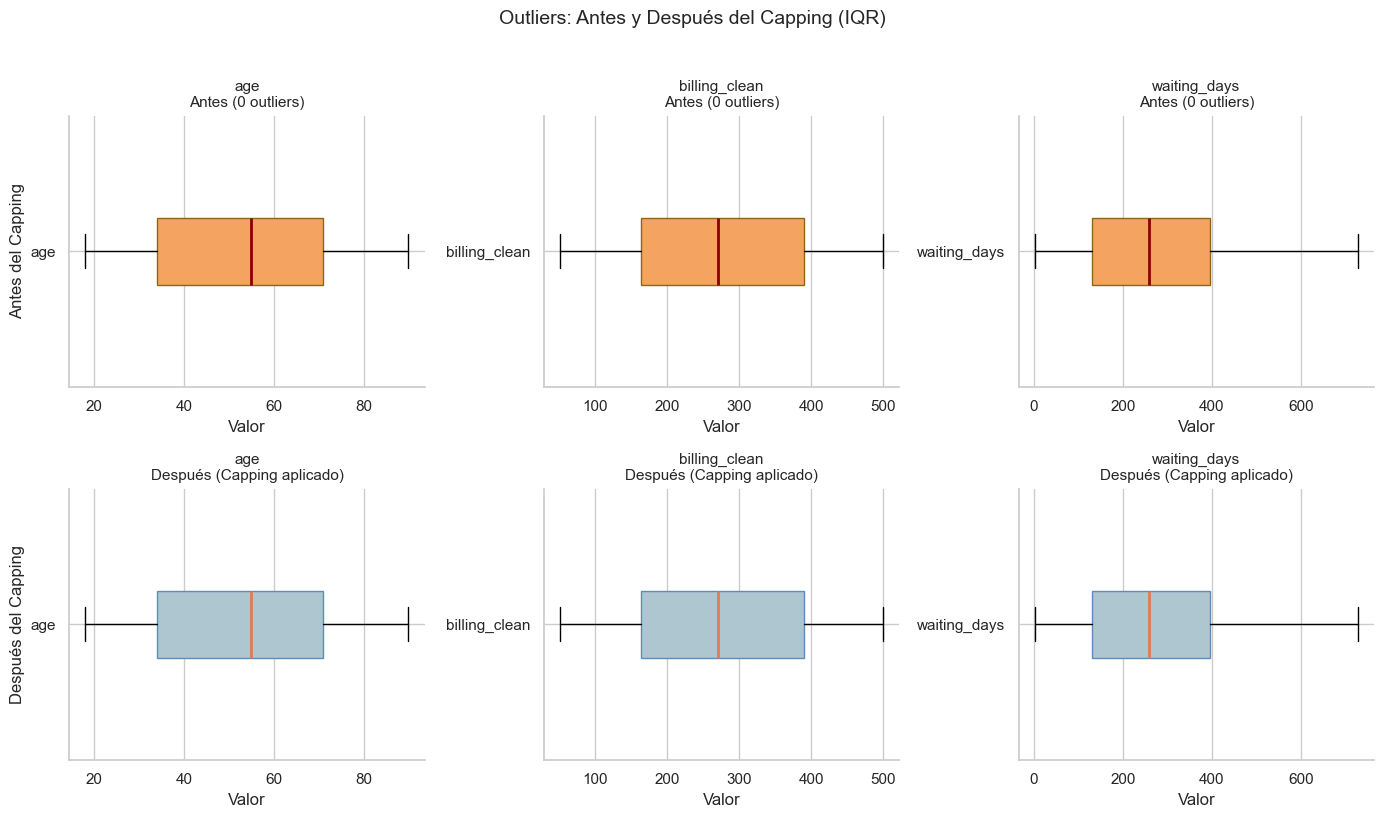

In [102]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
numeric_cols = ['age', 'billing_clean', 'waiting_days']

for i, col in enumerate(numeric_cols):
    serie = df[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    serie_capped = serie.clip(lower, upper)
    n_outliers = ((serie < lower) | (serie > upper)).sum()

    # Antes
    axes[0, i].boxplot(
        serie,
        vert=False,
        widths=0.25,
        patch_artist=True,
        boxprops=dict(facecolor='#F4A460', color='#8B6914'),
        medianprops=dict(color='#8B0000', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='#E07B54',
                        markersize=4, alpha=0.6)
    )
    axes[0, i].set_title(f'{col}\nAntes ({n_outliers} outliers)', fontsize=11)
    axes[0, i].set_xlabel('Valor')
    axes[0, i].set_yticks([1])
    axes[0, i].set_yticklabels([col])

    # Después
    axes[1, i].boxplot(
        serie_capped,
        vert=False,
        widths=0.25,
        patch_artist=True,
        boxprops=dict(facecolor='#AEC6CF', color='#5B8DB8'),
        medianprops=dict(color='#E07B54', linewidth=2)
    )
    axes[1, i].set_title(f'{col}\nDespués (Capping aplicado)', fontsize=11)
    axes[1, i].set_xlabel('Valor')
    axes[1, i].set_yticks([1])
    axes[1, i].set_yticklabels([col])

    print(f"{col}: {n_outliers} outliers | Límites: [{lower:.1f}, {upper:.1f}]")

axes[0, 0].set_ylabel('Antes del Capping', fontsize=12)
axes[1, 0].set_ylabel('Después del Capping', fontsize=12)
plt.suptitle('Outliers: Antes y Después del Capping (IQR)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'outliers_before_after.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 Variables categóricas: tasa de seguimiento por grupo

Analizamos qué porcentaje de pacientes necesita seguimiento según su departamento y género.


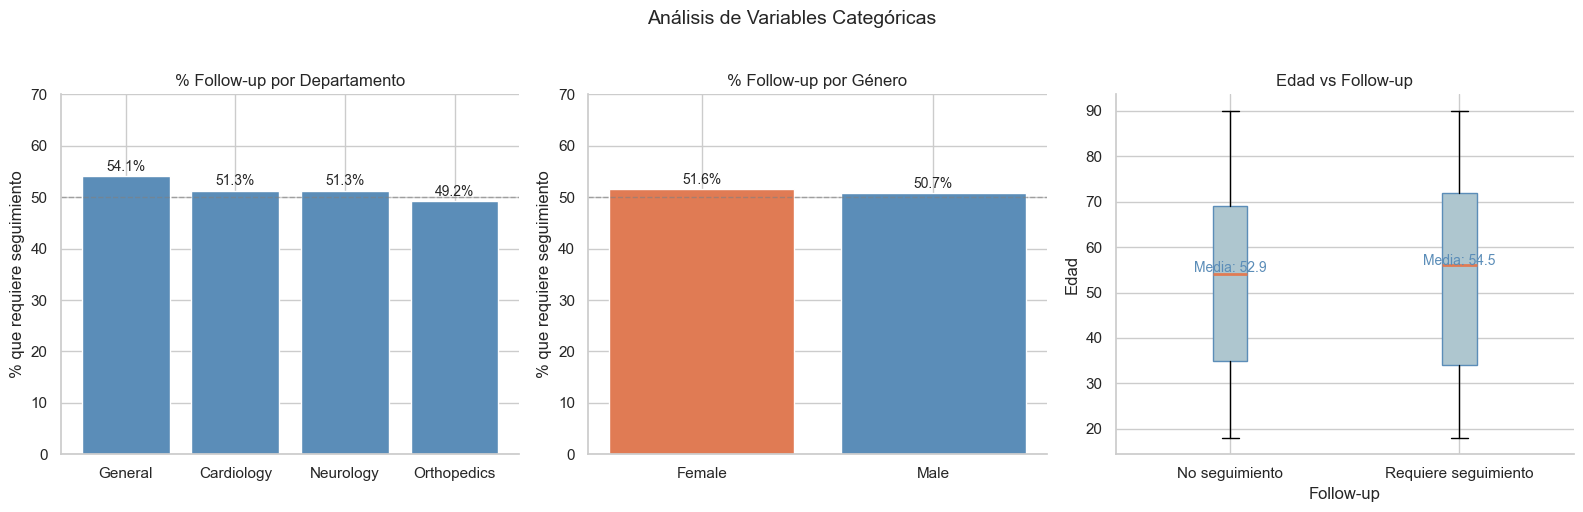

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Department
dept_follow = df.groupby('department')['follow_up_bin'].mean().sort_values(ascending=False)
bars = axes[0].bar(dept_follow.index, dept_follow.values * 100,
                   color='#5B8DB8', edgecolor='white')
axes[0].set_title('% Follow-up por Departamento', fontsize=12)
axes[0].set_ylabel('% que requiere seguimiento')
axes[0].set_ylim(0, 70)
axes[0].axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6)
for bar, val in zip(bars, dept_follow.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', fontsize=10)

# Gender vs follow_up
gen_follow = df.groupby('gender_norm')['follow_up_bin'].mean().dropna()
bars2 = axes[1].bar(gen_follow.index, gen_follow.values * 100,
                    color=['#E07B54', '#5B8DB8'], edgecolor='white')
axes[1].set_title('% Follow-up por Género', fontsize=12)
axes[1].set_ylabel('% que requiere seguimiento')
axes[1].set_ylim(0, 70)
axes[1].axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6)
for bar, val in zip(bars2, gen_follow.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', fontsize=10)

# Age vs follow_up
age_groups = [
    df[df['follow_up_bin'] == 0]['age'].dropna(),
    df[df['follow_up_bin'] == 1]['age'].dropna()
]
axes[2].boxplot(
    age_groups,
    labels=['No seguimiento', 'Requiere seguimiento'],
    patch_artist=True,
    boxprops=dict(facecolor='#AEC6CF', color='#5B8DB8'),
    medianprops=dict(color='#E07B54', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='#E07B54', markersize=4, alpha=0.6)
)
axes[2].set_title('Edad vs Follow-up', fontsize=12)
axes[2].set_ylabel('Edad')
axes[2].set_xlabel('Follow-up')
for x_pos, group in enumerate(age_groups, start=1):
    mean_age = group.mean()
    axes[2].text(x_pos, mean_age + 1.5, f'Media: {mean_age:.1f}',
                 ha='center', fontsize=10, color='#5B8DB8')

plt.suptitle('Análisis de Variables Categóricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


**Hallazgo crítico:** La columna `doctor` tiene **990 valores únicos** para 1000 filas.
Aplicar OneHotEncoding generaría ~990 columnas nuevas, lo que haría el modelo inviable
(maldición de la dimensionalidad). **Decisión:** se eliminará del pipeline junto con `patient_name`.


### 5.4 Pivot Table — Billing por Departamento y Género

Una `pivot_table` permite cruzar dos dimensiones simultáneamente.  
Aquí analizamos si el monto facturado varía según la combinación de departamento y género, lo que podría revelar patrones contextuales útiles.


In [104]:
# Pivot table: billing_amount medio por departamento × género
pivot_billing = pd.pivot_table(
    df,
    values='billing_clean',
    index='department',
    columns='gender_norm',
    aggfunc=['mean', 'count'],
    margins=True,        # Agrega fila/columna de totales
    margins_name='Total'
).round(2)

print("Billing Amount — Media y Conteo por Departamento × Género:")
pivot_billing


Billing Amount — Media y Conteo por Departamento × Género:


mean                  count           
gender_norm  Female    Male   Total Female Male Total
department                                           
Cardiology   247.25  271.04  259.42    106  111   217
General      294.29  295.10  294.65    116   92   208
Neurology    260.30  281.68  271.73    114  131   245
Orthopedics  284.05  271.54  278.23    124  108   232
Total        272.27  279.32  275.73    460  442   902

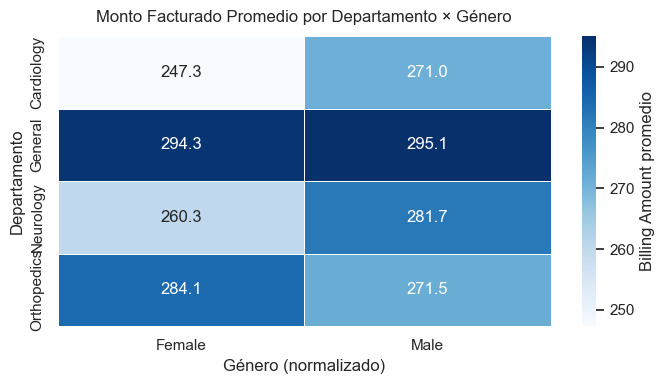


→ Los montos son similares entre géneros dentro de cada departamento.
→ General presenta la mayor facturación promedio (~$293).


In [105]:
# Visualización: heatmap de la pivot (solo la media)
pivot_mean = pd.pivot_table(
    df,
    values='billing_clean',
    index='department',
    columns='gender_norm',
    aggfunc='mean',
    fill_value=0
).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot_mean,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Billing Amount promedio'}
)
ax.set_title('Monto Facturado Promedio por Departamento × Género', fontsize=12, pad=10)
ax.set_xlabel('Género (normalizado)')
ax.set_ylabel('Departamento')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'pivot_billing_dept_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n→ Los montos son similares entre géneros dentro de cada departamento.")
print("→ General presenta la mayor facturación promedio (~$293).")


### 5.5 Enriquecimiento del Dataset con estadísticas por departamento

Calculamos estadísticas agregadas por departamento y las incorporamos al dataset mediante un `merge`.  
Esto permite que cada fila conozca el contexto de su departamento (tasa de seguimiento promedio, billing promedio), lo que puede ser una feature útil para el modelo.


In [106]:
# Paso 1: calcular estadísticas por departamento (agrupación múltiple)
dept_summary = df.groupby('department').agg(
    total_pacientes   = ('patient_id',     'count'),
    billing_promedio  = ('billing_clean',  'mean'),
    dias_espera_prom  = ('waiting_days',   'mean'),
    tasa_seguimiento  = ('follow_up_bin',  'mean'),
    billing_mediana   = ('billing_clean',  'median'),
).round(2).reset_index()

print("Estadísticas por departamento:")
dept_summary


Estadísticas por departamento:


,department,total_pacientes,billing_promedio,dias_espera_prom,tasa_seguimiento,billing_mediana
0,Cardiology,234,259.09,269.74,0.51,240.87
1,General,231,291.31,280.28,0.54,302.66
2,Neurology,273,275.16,271.36,0.51,274.81
3,Orthopedics,262,279.08,277.18,0.49,268.44


In [107]:
# Paso 2: merge LEFT — cada paciente hereda las estadísticas de su departamento
# 'left' conserva todos los registros originales aunque no haya match (no aplica aquí)
df_enriquecido = pd.merge(df, dept_summary, on='department', how='left')

print(f"Shape original:    {df.shape}")
print(f"Shape enriquecido: {df_enriquecido.shape}")
print(f"\nColumnas nuevas agregadas: {[c for c in df_enriquecido.columns if c not in df.columns]}")
print()

# Ejemplo de uso: comparar billing de cada paciente vs. promedio de su departamento
df_enriquecido['billing_vs_dept'] = (
    df_enriquecido['billing_clean'] - df_enriquecido['billing_promedio']
).round(2)

print("Primeras 5 filas — billing del paciente vs. promedio de su departamento:")
df_enriquecido[['patient_id','department','billing_clean','billing_promedio','billing_vs_dept']].head()


Shape original:    (1000, 16)
Shape enriquecido: (1000, 21)

Columnas nuevas agregadas: ['total_pacientes', 'billing_promedio', 'dias_espera_prom', 'tasa_seguimiento', 'billing_mediana']

Primeras 5 filas — billing del paciente vs. promedio de su departamento:


,patient_id,department,billing_clean,billing_promedio,billing_vs_dept
0,1080,Cardiology,425.80,259.09,166.71
1,1074,Orthopedics,344.26,279.08,65.18
2,1067,Neurology,203.34,275.16,-71.82
3,1072,General,85.76,291.31,-205.55
4,1092,General,84.44,291.31,-206.87


### 5.6 Matriz de Correlación

Síntesis visual de las relaciones lineales entre todas las variables numéricas y el target.  
Permite identificar cuáles variables tienen mayor correlación con `follow_up_bin` y si hay multicolinealidad entre predictores.


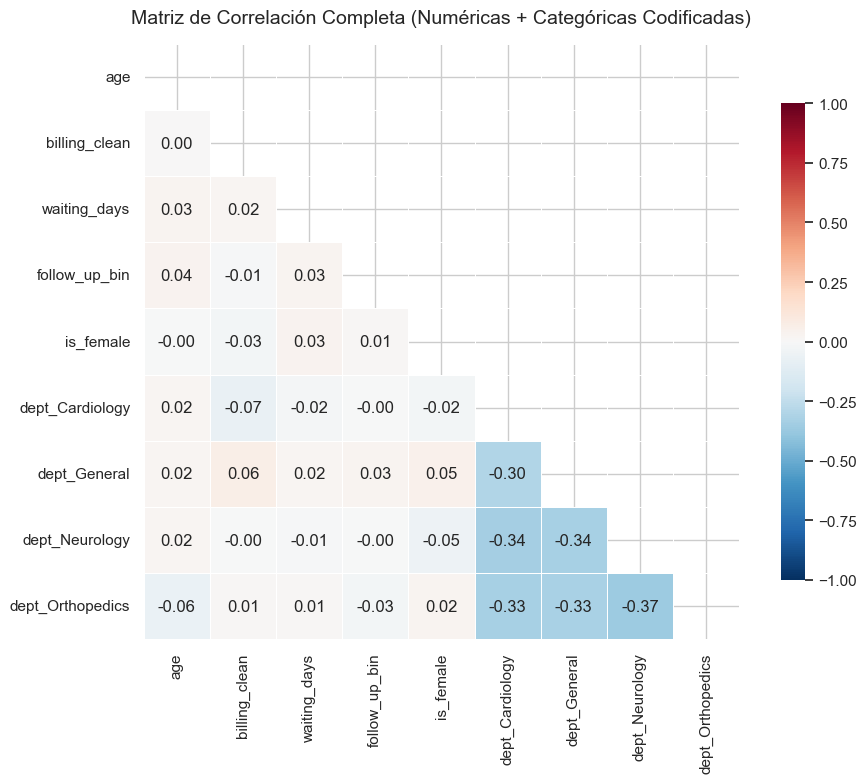


Interpretación:
- Valores cerca de 1 o -1 en la fila/columna de 'follow_up_bin' indican buenos predictores.
- Valores altos entre otras variables (ej. dept_Cardiology vs age) indican perfiles de pacientes, pero si son demasiado altos (>0.8) podría haber redundancia.


In [113]:
# --- REEMPLAZO FASE 5.6: MATRIZ DE CORRELACIÓN COMPLETA ---
# Seleccionamos numéricas
cols_num = ['age', 'billing_clean', 'waiting_days', 'follow_up_bin']
df_corr = df[cols_num].copy()

# Convertimos 'gender_norm' a número (Ej: Female=1, Male=0)
# Usamos map, si hay nulos quedarán como NaN por ahora, lo cual pandas.corr() ignora inteligentemente
df_corr['is_female'] = df['gender_norm'].map({'Female': 1, 'Male': 0})

# Convertimos 'department' a columnas binarias (One-Hot Encoding)
# Esto creará columnas como 'dept_Cardiology', 'dept_General', etc.
df_dept = pd.get_dummies(df['department'], prefix='dept', drop_first=False)
df_corr = pd.concat([df_corr, df_dept], axis=1)

# Calculamos la matriz con todas las variables relevantes
matriz = df_corr.corr()

# Gráfico
mask = np.triu(np.ones_like(matriz, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8)) # Un poco más grande para que quepan todas
sns.heatmap(
    matriz,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlación Completa (Numéricas + Categóricas Codificadas)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'full_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretación:")
print("- Valores cerca de 1 o -1 en la fila/columna de 'follow_up_bin' indican buenos predictores.")
print("- Valores altos entre otras variables (ej. dept_Cardiology vs age) indican perfiles de pacientes, pero si son demasiado altos (>0.8) podría haber redundancia.")

### 5.7 ANÁLISIS BIVARIADO (Día de la semana vs Target)

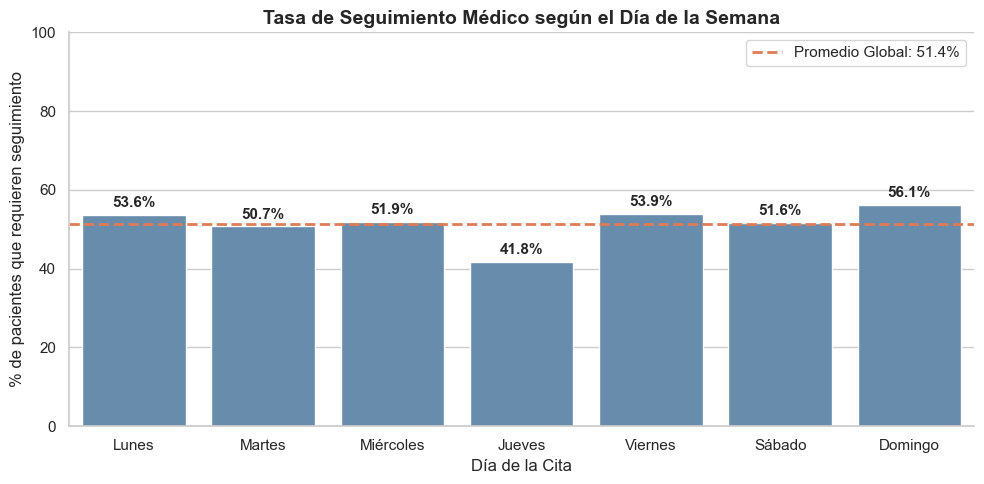

In [22]:
# --- FASE 5: ANÁLISIS BIVARIADO (Día de la semana vs Target) ---
# 1. Mapear los números (0-6) a nombres de días para que el gráfico se lea bien
dias_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
df['dia_nombre'] = df['appointment_dow'].map(dias_map)

# 2. Calcular el porcentaje promedio de seguimiento por cada día
dow_follow = df.groupby('dia_nombre')['follow_up_bin'].mean().reindex(dias_map.values()) * 100

# 3. Visualización
fig, ax = plt.subplots(figsize=(10, 5))

# Crear gráfico de barras
sns.barplot(
    x=dow_follow.index, 
    y=dow_follow.values, 
    color='#5B8DB8', 
    ax=ax
)

# Añadir una línea roja que marque el promedio general del dataset
promedio_general = df['follow_up_bin'].mean() * 100
ax.axhline(promedio_general, color='#E07B54', linestyle='--', linewidth=2, 
           label=f'Promedio Global: {promedio_general:.1f}%')

# Detalles estéticos
ax.set_title('Tasa de Seguimiento Médico según el Día de la Semana', fontsize=14, fontweight='bold')
ax.set_xlabel('Día de la Cita')
ax.set_ylabel('% de pacientes que requieren seguimiento')
ax.set_ylim(0, 100) # El eje Y va de 0 a 100%
ax.legend()

# Poner los valores exactos sobre cada barra
for i, val in enumerate(dow_follow.values):
    ax.text(i, val + 2, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'dow_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

# Limpiar columna temporal
df.drop(columns=['dia_nombre'], inplace=True, errors='ignore')

---
## FASE 6 — Síntesis, Optimización y Conclusiones

> *¿Qué aprendimos? ¿Qué entra al modelo y qué no?*

Esta fase cierra el EDA con las conclusiones para el pipeline de modelado.


### 6.1 Optimización de memoria (Downcasting)

Antes de pasar al pipeline, reducimos el uso de memoria aplicando downcasting de tipos de datos.  
Esto es especialmente relevante cuando el dataset crece.


INFO: Procesando c:\GitHub\EDA-Messy-Clinic-Appointments\notebooks\..\data\raw\messy_clinic_appointments.csv en bloques de 250 filas...
INFO:   Bloque 1: 250 filas procesadas.


INFO:   Bloque 2: 250 filas procesadas.
INFO:   Bloque 3: 250 filas procesadas.
INFO:   Bloque 4: 250 filas procesadas.
INFO: Procesamiento completado. Total de filas: 1000
INFO: Iniciando optimización de memoria (downcasting)...
INFO: Memoria inicial: 0.0362 MB
INFO: Memoria optimizada: 0.0145 MB
INFO: Reducción lograda:  60.0%


=== Procesamiento por bloques (simulación gran escala) ===
Total procesado: 1000 filas

=== Downcasting de tipos de datos ===
Memoria usada por columna (bytes):
               Antes  Después
Index           7600     7600
age             7600      950
billing_clean   7600     3800
waiting_days    7600     1900
follow_up_bin   7600      950

Total antes:  38,000 bytes
Total después:15,200 bytes


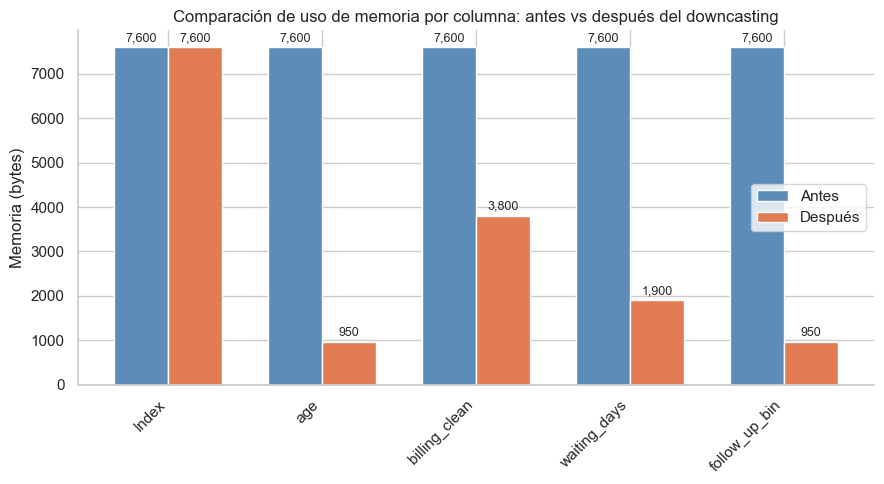

In [23]:
from src.optimization import optimize_memory_usage, process_large_file_in_chunks

print("=== Procesamiento por bloques (simulación gran escala) ===")
total = process_large_file_in_chunks(str(RAW_CSV), chunk_size=250)
print(f"Total procesado: {total} filas\n")

print("=== Downcasting de tipos de datos ===")
df_numeric = df[['age', 'billing_clean', 'waiting_days', 'follow_up_bin']].dropna()

mem_before = df_numeric.memory_usage(deep=True)
df_optimized = optimize_memory_usage(df_numeric)
mem_after = df_optimized.memory_usage(deep=True)

mem_compare = pd.DataFrame({
    'Antes': mem_before,
    'Después': mem_after
}).astype(int)

print("Memoria usada por columna (bytes):")
print(mem_compare)
print(f"\nTotal antes:  {mem_compare['Antes'].sum():,} bytes")
print(f"Total después:{mem_compare['Después'].sum():,} bytes")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(mem_compare))
width = 0.35

ax.bar(x - width/2, mem_compare['Antes'], width, label='Antes', color='#5B8DB8')
ax.bar(x + width/2, mem_compare['Después'], width, label='Después', color='#E07B54')

ax.set_xticks(x)
ax.set_xticklabels(mem_compare.index, rotation=45, ha='right')
ax.set_ylabel('Memoria (bytes)')
ax.set_title('Comparación de uso de memoria por columna: antes vs después del downcasting')
ax.legend()

for xi, antes, despues in zip(x, mem_compare['Antes'], mem_compare['Después']):
    ax.text(xi - width/2, antes + max(mem_compare.values.flatten()) * 0.01,
            f'{antes:,}', ha='center', va='bottom', fontsize=9)
    ax.text(xi + width/2, despues + max(mem_compare.values.flatten()) * 0.01,
            f'{despues:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'memory_usage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Procesamiento por bloques (Chunking para gran escala)

En un escenario real con millones de filas que no caben en RAM, procesamos el archivo en bloques y acumulamos resultados parciales antes de combinarlos.  
Este patrón es escalable y reproducible.


In [110]:
# Procesamiento en bloques con agregación acumulativa
# Simulamos un dataset "masivo" leyendo el mismo CSV en bloques de 100 filas

resultados_parciales = []   # Lista donde acumulamos el resumen de cada bloque

for i, chunk in enumerate(pd.read_csv(RAW_CSV, chunksize=100)):

    # Limpieza local del bloque
    billing_num = (
        chunk['billing_amount']
        .astype(str)
        .str.strip()
        .replace(r'^\.+$', np.nan, regex=True)
        .str.replace(r'[^\d.,]+', '', regex=True)
        .str.replace(',', '.', regex=False)
    )
    billing_num = pd.to_numeric(billing_num, errors='coerce')

    # Agregación parcial de este bloque
    resumen_bloque = {
        'bloque':         i + 1,
        'n_filas':        len(chunk),
        'billing_sum':    billing_num.sum(),
        'billing_count':  billing_num.notna().sum(),
    }
    resultados_parciales.append(resumen_bloque)

# Combinar todos los bloques
df_chunks = pd.DataFrame(resultados_parciales)

# Calcular estadística global a partir de los parciales
billing_global_media = df_chunks['billing_sum'].sum() / df_chunks['billing_count'].sum()

print(f"Bloques procesados:   {len(df_chunks)}")
print(f"Total filas:          {df_chunks['n_filas'].sum()}")
print(f"Media billing global: ${billing_global_media:.2f}")
print()
print("Resumen por bloque (primeros 5):")
df_chunks.head()


Bloques procesados:   10
Total filas:          1000
Media billing global: $276.12

Resumen por bloque (primeros 5):


,bloque,n_filas,billing_sum,billing_count
0,1,100,24952.32,96
1,2,100,24977.33,94
2,3,100,28098.14,92
3,4,100,25239.24,95
4,5,100,27940.94,96


### 6.3 Conclusiones del EDA

**Features con señal predictiva detectada:**
- `waiting_days` — distribuciones diferenciadas entre clases
- `department` — tasas de seguimiento variables por área
- `billing_clean` — correlación con el target
- `appointment_dow` — patrón temporal en días de semana

**Variables a eliminar del pipeline:**
- `doctor` → 990 valores únicos (maldición de la dimensionalidad)
- `patient_name` → sin valor predictivo

**Features finales para el modelo:**
- Numéricas: `age`, `billing_amount`, `waiting_days`
- Categóricas: `gender`, `department`
- Feature nueva: `appointment_dow`

**Observación clave:** el target `follow_up_required` está prácticamente balanceado (~51%/49%), por lo que **no se necesitan técnicas de balanceo** como SMOTE o `class_weight`.

---
